# Task 2: Credit Risk Prediction

## Introduction & Problem Statement

**Credit risk** is the likelihood that a borrower will fail to meet their loan obligations. Banks and financial institutions rely on predictive models to assess applicant risk before approving loans.

**Objective:** Perform EDA on the loan applicant dataset, handle missing values, visualize key features, and build a binary classification model to predict **Credit History** (used here as the risk proxy: `1` = good credit / likely repays, `0` = bad credit / likely defaults).



**Dataset:** `task2_dataset.csv` — 367 loan applicants

| Feature | Type | Description |
|---|---|---|
| `Gender` | Categorical | Male / Female |
| `Married` | Categorical | Yes / No |
| `Dependents` | Categorical | 0 / 1 / 2 / 3+ |
| `Education` | Categorical | Graduate / Not Graduate |
| `Self_Employed` | Categorical | Yes / No |
| `ApplicantIncome` | Numeric | Monthly income of applicant |
| `CoapplicantIncome` | Numeric | Monthly income of co-applicant |
| `LoanAmount` | Numeric | Loan amount (thousands) |
| `Loan_Amount_Term` | Numeric | Term in months |
| `Credit_History` | Numeric | **Target** — 1 = Good, 0 = Bad |
| `Property_Area` | Categorical | Urban / Semiurban / Rural |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
print('Libraries loaded!')

Libraries loaded!


## 2. Dataset Understanding & Description

In [2]:
# Load the dataset
df = pd.read_csv('task2_dataset.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (367, 12)
Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


## 3. Data Cleaning & Preparation

Columns with missing values:
Gender              11
Dependents          10
Self_Employed       23
LoanAmount           5
Loan_Amount_Term     6
Credit_History      29
dtype: int64


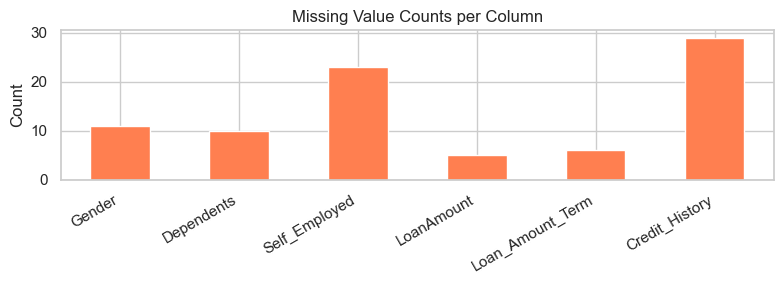

In [6]:
# Visualize missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)

plt.figure(figsize=(8, 3))
missing.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Missing Value Counts per Column')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Drop Loan_ID — not a predictive feature
df.drop(columns=['Loan_ID'], inplace=True)

# Impute categorical columns with mode
for col in ['Gender', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Impute numeric columns with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# For Credit_History (our target), drop rows where it is missing
df.dropna(subset=['Credit_History'], inplace=True)

print(f'Shape after cleaning: {df.shape}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Shape after cleaning: (338, 11)
Remaining missing values: 0


In [8]:
# Encode all categorical features with Label Encoding
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Convert target to integer
df['Credit_History'] = df['Credit_History'].astype(int)

print('Encoding complete.')
df.head(3)

Encoding complete.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,5720,0,110.0,360.0,1,2
1,1,1,1,0,0,3076,1500,126.0,360.0,1,2
2,1,1,2,0,0,5000,1800,208.0,360.0,1,2


## 4. Exploratory Data Analysis (EDA)

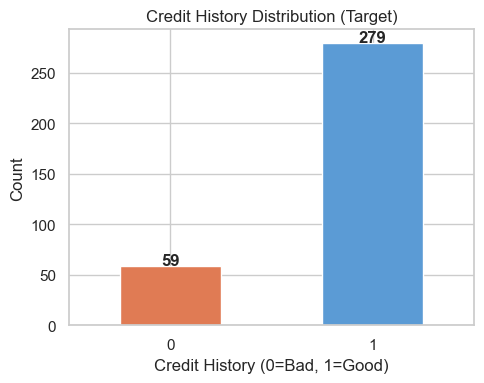

In [9]:
# Target distribution
plt.figure(figsize=(5, 4))
ax = df['Credit_History'].value_counts().sort_index().plot(
    kind='bar', color=['#E07B54', '#5B9BD5'], edgecolor='white', width=0.5
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha='center', fontweight='bold')
plt.title('Credit History Distribution (Target)')
plt.xlabel('Credit History (0=Bad, 1=Good)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

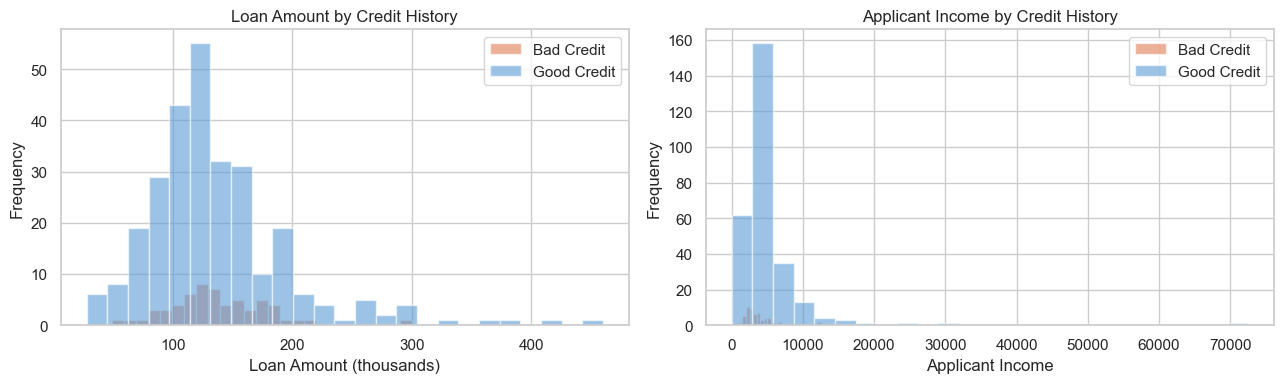

In [10]:
# Loan Amount and Applicant Income distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for val, label, color in [(0, 'Bad Credit', '#E07B54'), (1, 'Good Credit', '#5B9BD5')]:
    axes[0].hist(df[df['Credit_History']==val]['LoanAmount'],
                 bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[1].hist(df[df['Credit_History']==val]['ApplicantIncome'],
                 bins=25, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title('Loan Amount by Credit History')
axes[0].set_xlabel('Loan Amount (thousands)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Applicant Income by Credit History')
axes[1].set_xlabel('Applicant Income')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

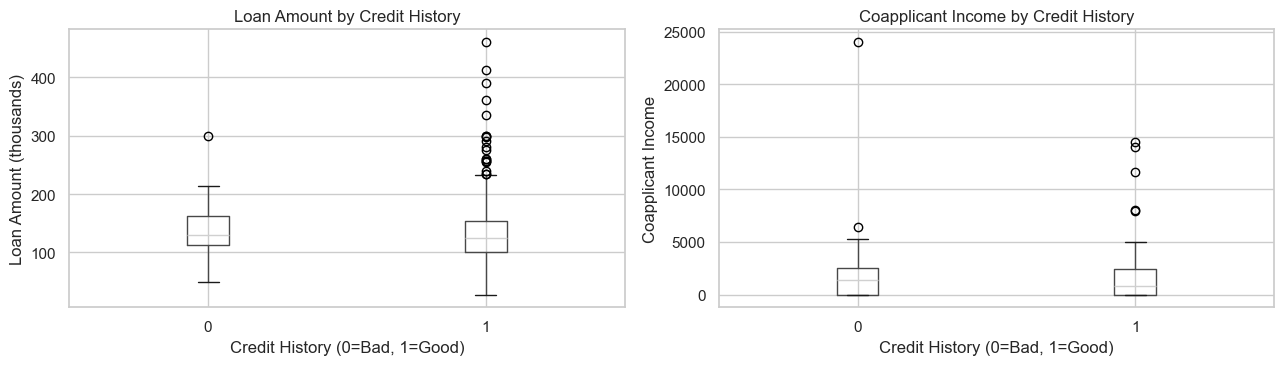

In [11]:
# Box plots: LoanAmount and CoapplicantIncome by Credit History
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.boxplot(column='LoanAmount', by='Credit_History', ax=axes[0])
axes[0].set_title('Loan Amount by Credit History')
axes[0].set_xlabel('Credit History (0=Bad, 1=Good)')
axes[0].set_ylabel('Loan Amount (thousands)')

df.boxplot(column='CoapplicantIncome', by='Credit_History', ax=axes[1])
axes[1].set_title('Coapplicant Income by Credit History')
axes[1].set_xlabel('Credit History (0=Bad, 1=Good)')
axes[1].set_ylabel('Coapplicant Income')

plt.suptitle('')
plt.tight_layout()
plt.show()

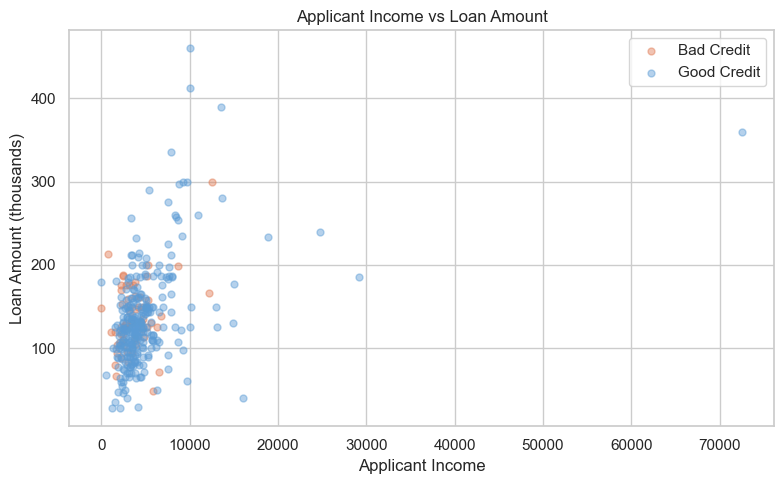

In [12]:
# Scatter: Applicant Income vs Loan Amount coloured by Credit History
plt.figure(figsize=(8, 5))
for val, label, color in [(0, 'Bad Credit', '#E07B54'), (1, 'Good Credit', '#5B9BD5')]:
    sub = df[df['Credit_History'] == val]
    plt.scatter(sub['ApplicantIncome'], sub['LoanAmount'],
                alpha=0.45, s=25, label=label, color=color)
plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount (thousands)')
plt.legend()
plt.tight_layout()
plt.show()

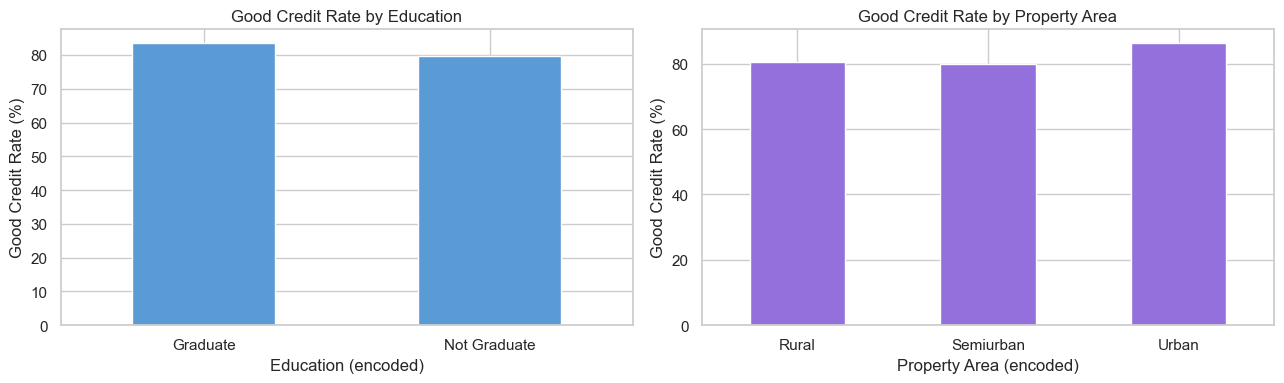

In [13]:
# Good credit rate by Education and Property Area
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

edu_rate = df.groupby('Education')['Credit_History'].mean() * 100
edu_rate.plot(kind='bar', ax=axes[0], color='#5B9BD5', edgecolor='white')
axes[0].set_title('Good Credit Rate by Education')
axes[0].set_xlabel('Education (encoded)')
axes[0].set_ylabel('Good Credit Rate (%)')
axes[0].set_xticklabels(['Graduate', 'Not Graduate'], rotation=0)

prop_rate = df.groupby('Property_Area')['Credit_History'].mean() * 100
prop_rate.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Good Credit Rate by Property Area')
axes[1].set_xlabel('Property Area (encoded)')
axes[1].set_ylabel('Good Credit Rate (%)')
axes[1].set_xticklabels(['Rural', 'Semiurban', 'Urban'], rotation=0)

plt.tight_layout()
plt.show()

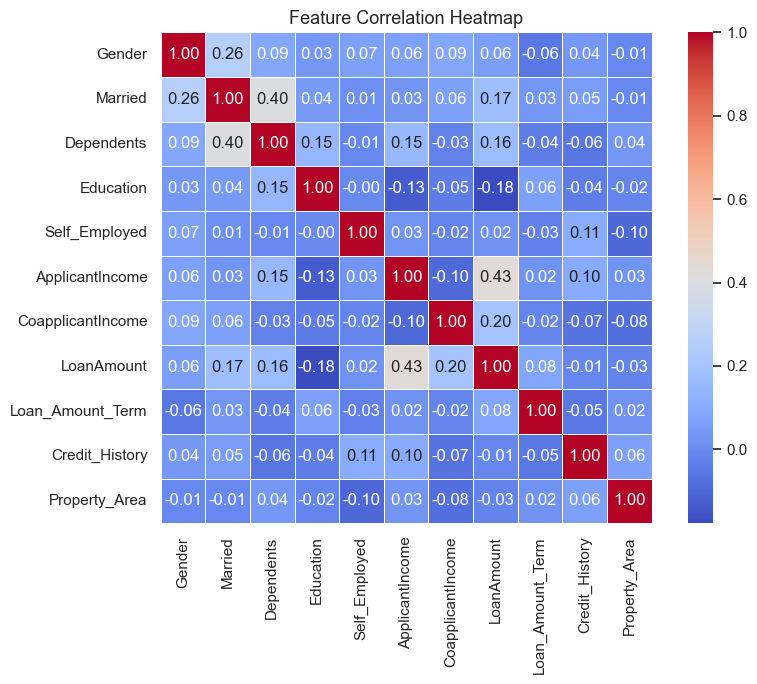

In [14]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Model Training & Testing

In [15]:
X = df.drop(columns=['Credit_History'])
y = df['Credit_History']

# Standardise for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 270 | Test: 68


In [16]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('Models trained!')

Models trained!


## 6. Evaluation Metrics

In [17]:
for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Decision Tree',       y_pred_dt, y_prob_dt)
]:
    print(f'--- {name} ---')
    print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}\n')

--- Logistic Regression ---
  Accuracy : 0.8235
  ROC-AUC  : 0.5952

--- Decision Tree ---
  Accuracy : 0.8088
  ROC-AUC  : 0.6220



In [18]:
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Bad Credit', 'Good Credit']))
print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['Bad Credit', 'Good Credit']))

=== Logistic Regression ===
              precision    recall  f1-score   support

  Bad Credit       0.00      0.00      0.00        12
 Good Credit       0.82      1.00      0.90        56

    accuracy                           0.82        68
   macro avg       0.41      0.50      0.45        68
weighted avg       0.68      0.82      0.74        68

=== Decision Tree ===
              precision    recall  f1-score   support

  Bad Credit       0.33      0.08      0.13        12
 Good Credit       0.83      0.96      0.89        56

    accuracy                           0.81        68
   macro avg       0.58      0.52      0.51        68
weighted avg       0.74      0.81      0.76        68



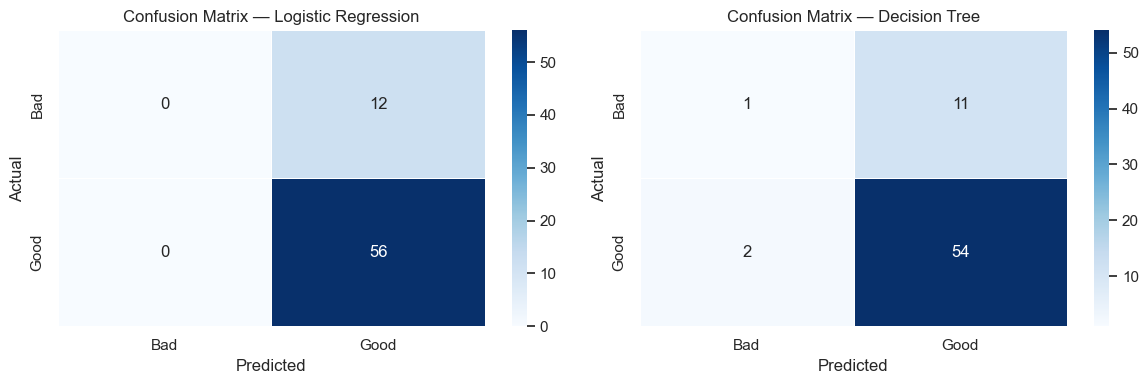

In [19]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(axes,
    [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']):
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=['Bad', 'Good'],
                yticklabels=['Bad', 'Good'], ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

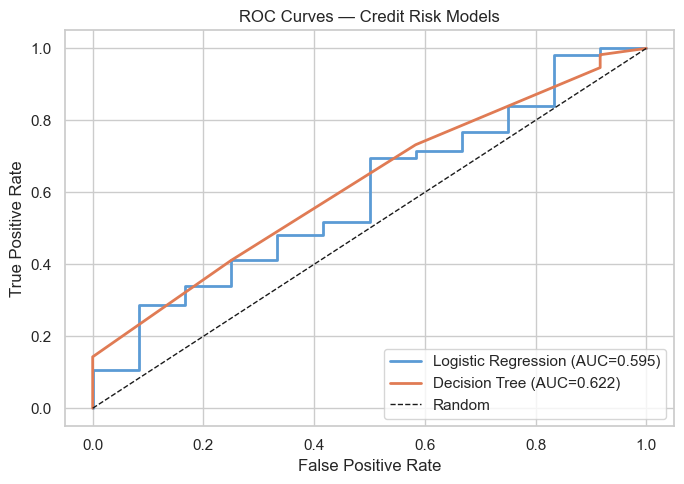

In [20]:
# ROC Curves
plt.figure(figsize=(7, 5))
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#5B9BD5'),
    ('Decision Tree',       y_prob_dt, '#E07B54')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Credit Risk Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

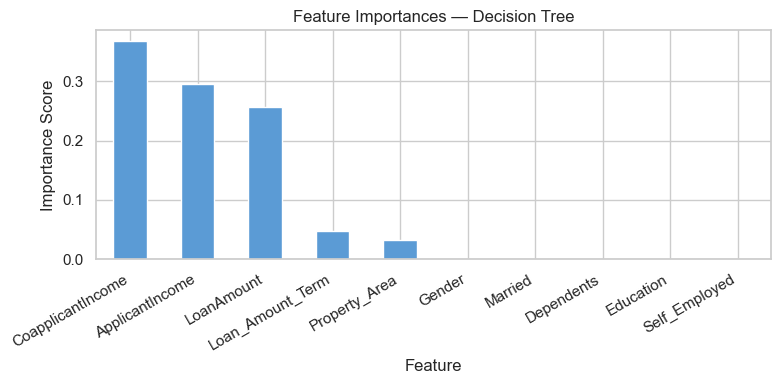

CoapplicantIncome    0.3675
ApplicantIncome      0.2954
LoanAmount           0.2571
Loan_Amount_Term     0.0479
Property_Area        0.0321
Gender               0.0000
Married              0.0000
Dependents           0.0000
Education            0.0000
Self_Employed        0.0000


In [21]:
# Feature importances — Decision Tree
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='#5B9BD5', edgecolor='white')
plt.title('Feature Importances — Decision Tree')
plt.xlabel('Feature'); plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(importances.round(4).to_string())

## 7. Conclusion

### Key Insights :

1. **Missing values** were present in `Gender` (11), `Dependents` (10), `Self_Employed` (23), `LoanAmount` (5), `Loan_Amount_Term` (6), and `Credit_History` (29). Mode/median imputation was applied; rows with missing target were dropped.
2. **Class imbalance** exists — ~82% of applicants have good credit history (1), reflecting real-world loan portfolio composition.
3. **LoanAmount** and **ApplicantIncome** show right-skewed distributions, with high-income outliers visible in the scatter plot.
4. **Property Area** and **Education** influence credit quality — Semiurban applicants and Graduates tend to have slightly higher good-credit rates.
5. Both models perform well on the majority class; ROC-AUC better captures performance on the imbalanced minority class.
6. The **Decision Tree feature importances** reveal which financial and demographic factors most influence credit risk.
